# Lab Problem Statement 6: Customer Segmentation and Predictive Analytics Using Machine Learning

**Platform:** Kaggle Notebook  
**Language:** R  
**Dataset:** UCI Machine Learning Repository – Online Retail

## Objective
Build an end-to-end customer analytics solution that:
1. preprocesses transaction-level data;
2. engineers customer-level RFM and behavioral features;
3. performs K-Means and Hierarchical Clustering;
4. selects the number of clusters using the Elbow Method and Silhouette Score;
5. applies PCA and visualizes customer segments;
6. profiles the clusters and creates segment-wise marketing recommendations;
7. identifies the cluster with the highest monetary value as a high-value segment;
8. trains Random Forest and SVM models to predict high-value membership;
9. compares Accuracy, Precision, Recall, F1-Score, ROC-AUC, and Confusion Matrix;
10. analyzes feature importance; and
11. creates an interactive 3D Plotly visualization.

> **Note:** The supervised target is derived from the generated customer clusters. Therefore, the prediction task estimates **cluster membership**, rather than an independent future revenue outcome.

In [1]:
# This R environment comes with many helpful analytics packages installed
# It is defined by the kaggle/rstats Docker image: https://github.com/kaggle/docker-rstats
# For example, here's a helpful package to load

library(tidyverse) # metapackage of all tidyverse packages

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

list.files(path = "../input")

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


[1] "datasets"

## Dataset Description

The original UCI Online Retail dataset contains 541,909 transaction records from a UK-based, non-store online retailer. It contains transaction identifiers, product information, quantity, invoice date, unit price, customer ID, and country. Invoice numbers beginning with **C** indicate cancellations.

**UCI source:** https://archive.ics.uci.edu/dataset/352/online+retail  
**Citation:** Chen, D. (2015). *Online Retail*. UCI Machine Learning Repository. DOI: 10.24432/C5BW33.

In [2]:
# 1. Package installation and loading

required_packages <- c(
  "readxl", "dplyr", "tidyr", "ggplot2", "cluster",
  "randomForest", "e1071", "pROC", "plotly", "scales"
)

installed <- rownames(installed.packages())
to_install <- setdiff(required_packages, installed)

if (length(to_install) > 0) {
  install.packages(to_install, repos = "https://cloud.r-project.org")
}

suppressPackageStartupMessages({
  library(readxl)
  library(dplyr)
  library(tidyr)
  library(ggplot2)
  library(cluster)
  library(randomForest)
  library(e1071)
  library(pROC)
  library(plotly)
  library(scales)
})

set.seed(123)

options(stringsAsFactors = FALSE)

In [3]:
# 2. Locate the dataset
#    Priority:
#    (a) Kaggle attached dataset under /kaggle/input
#    (b) UCI Online Retail ZIP downloaded to /kaggle/working

find_online_retail_file <- function(root = "/kaggle/input") {
  if (!dir.exists(root)) return(character(0))

  candidates <- list.files(
    root,
    pattern = "\\.(xlsx|xls|csv|parquet)$",
    recursive = TRUE,
    full.names = TRUE,
    ignore.case = TRUE
  )

  if (length(candidates) == 0) return(character(0))

  preferred <- candidates[
    grepl(
      "online.?retail|online_retail|retail|ecommerce|e.?commerce",
      basename(candidates),
      ignore.case = TRUE
    )
  ]

  if (length(preferred) > 0) preferred[1] else candidates[1]
}

data_file <- find_online_retail_file()

if (length(data_file) == 0) {
  dir.create(
    "/kaggle/working/uci_online_retail",
    showWarnings = FALSE,
    recursive = TRUE
  )

  zip_file <- "/kaggle/working/online_retail.zip"
  uci_url <- "https://archive.ics.uci.edu/static/public/352/online%2Bretail.zip"

  if (!file.exists(zip_file)) {
    download.file(uci_url, zip_file, mode = "wb")
  }

  unzip(zip_file, exdir = "/kaggle/working/uci_online_retail")

  extracted <- list.files(
    "/kaggle/working/uci_online_retail",
    pattern = "\\.(xlsx|xls|csv)$",
    recursive = TRUE,
    full.names = TRUE,
    ignore.case = TRUE
  )

  preferred_extracted <- extracted[
    grepl(
      "online.?retail|online_retail|retail",
      basename(extracted),
      ignore.case = TRUE
    )
  ]

  data_file <- if (length(preferred_extracted) > 0) {
    preferred_extracted[1]
  } else {
    extracted[1]
  }
}

cat("Dataset file:", data_file, "\n")

Dataset file: /kaggle/input/datasets/mashlyn/online-retail-ii-uci/online_retail_II.csv 


### Kaggle column-name compatibility

This notebook automatically maps common variants such as `Invoice`, `Invoice Number`, `Price`, `Unit Price`, `Customer`, and `Customer ID` to the UCI Online Retail schema. This prevents errors caused by Kaggle datasets that rename columns.


In [4]:
# 3. Read transaction-level data
#    Robustly normalize common Kaggle/UCI column-name variants.

if (grepl("\\.(xlsx|xls)$", data_file, ignore.case = TRUE)) {
  sheets <- excel_sheets(data_file)
  cat("Excel sheets:", paste(sheets, collapse = ", "), "\n")
  raw_data <- read_excel(data_file)
} else {
  raw_data <- read.csv(
    data_file,
    check.names = FALSE,
    stringsAsFactors = FALSE
  )
}

# Helper: convert arbitrary column names into a comparison key.
normalize_key <- function(x) {
  x <- trimws(as.character(x))
  x <- gsub("[^A-Za-z0-9]", "", x)
  tolower(x)
}

# Map common variants to the UCI Online Retail schema.
# Examples:
#   Invoice / Invoice Number / InvoiceNo  -> InvoiceNo
#   Price / Unit Price / UnitPrice         -> UnitPrice
#   Customer / Customer ID / CustomerID    -> CustomerID
#   Description / Product Description      -> Description
#   Stock Code / StockCode                 -> StockCode
#   Invoice Date / InvoiceDate             -> InvoiceDate
#   Qty / Quantity                         -> Quantity
#   Country / CountryName                  -> Country
canonical_aliases <- list(
  InvoiceNo = c(
    "invoiceno", "invoice", "invoicenumber", "invoicenumberid"
  ),
  StockCode = c(
    "stockcode", "stock", "itemcode", "productcode", "sku"
  ),
  Description = c(
    "description", "productdescription", "product", "itemdescription"
  ),
  Quantity = c(
    "quantity", "qty", "units", "unitsordered"
  ),
  InvoiceDate = c(
    "invoicedate", "invoicedatetime", "date", "transactiondate", "orderdate"
  ),
  UnitPrice = c(
    "unitprice", "price", "unitcost", "saleprice", "sellingprice"
  ),
  CustomerID = c(
    "customerid", "customer", "customeridnumber", "clientid", "customer_no"
  ),
  Country = c(
    "country", "countryname", "nation"
  )
)

original_names <- names(raw_data)
keys <- normalize_key(original_names)

# First pass: exact/alias matching.
rename_map <- setNames(character(0), character(0))

for (canonical in names(canonical_aliases)) {
  aliases <- normalize_key(c(canonical, canonical_aliases[[canonical]]))
  hit <- which(keys %in% aliases)

  if (length(hit) > 0) {
    # Keep the first matching source column.
    rename_map[original_names[hit[1]]] <- canonical
  }
}

# Second pass: fuzzy matching for troublesome Kaggle variants.
# Only used when an exact alias was not found.
fuzzy_candidates <- list(
  InvoiceNo = c("invoice"),
  UnitPrice = c("price", "unitprice"),
  CustomerID = c("customer"),
  InvoiceDate = c("invoice", "date"),
  Quantity = c("quantity", "qty"),
  StockCode = c("stock", "code", "sku"),
  Description = c("description", "product"),
  Country = c("country")
)

for (canonical in names(fuzzy_candidates)) {
  if (canonical %in% unname(rename_map)) next

  pattern <- paste(
    fuzzy_candidates[[canonical]],
    collapse = "|"
  )

  hit <- grep(pattern, keys, ignore.case = TRUE)

  # Prefer a unique fuzzy match to avoid accidental renaming.
  if (length(hit) == 1) {
    rename_map[original_names[hit]] <- canonical
  }
}

if (length(rename_map) > 0) {
  for (old_name in names(rename_map)) {
    new_name <- unname(rename_map[[old_name]])
    names(raw_data)[names(raw_data) == old_name] <- new_name
  }
}

cat("Detected/standardized columns:\n")
print(names(raw_data))

required_cols <- c(
  "InvoiceNo", "StockCode", "Description",
  "Quantity", "InvoiceDate", "UnitPrice",
  "CustomerID", "Country"
)

missing_required <- setdiff(required_cols, names(raw_data))

if (length(missing_required) > 0) {
  stop(
    paste0(
      "Required columns are missing after automatic column mapping: ",
      paste(missing_required, collapse = ", "),
      "\n\nDetected columns are:\n",
      paste(names(raw_data), collapse = ", "),
      "\n\nTip: if your Kaggle dataset uses different field names, "
      ,"edit canonical_aliases in this cell."
    )
  )
}

cat("Rows:", nrow(raw_data), "\n")
cat("Columns:", ncol(raw_data), "\n")
print(head(raw_data))

Detected/standardized columns:
[1] "InvoiceNo"   "StockCode"   "Description" "Quantity"    "InvoiceDate"
[6] "UnitPrice"   "CustomerID"  "Country"    
Rows: 1067371 
Columns: 8 
  InvoiceNo StockCode                         Description Quantity
1    489434     85048 15CM CHRISTMAS GLASS BALL 20 LIGHTS       12
2    489434    79323P                  PINK CHERRY LIGHTS       12
3    489434    79323W                 WHITE CHERRY LIGHTS       12
4    489434     22041        RECORD FRAME 7" SINGLE SIZE        48
5    489434     21232      STRAWBERRY CERAMIC TRINKET BOX       24
6    489434     22064          PINK DOUGHNUT TRINKET POT        24
          InvoiceDate UnitPrice CustomerID        Country
1 2009-12-01 07:45:00      6.95      13085 United Kingdom
2 2009-12-01 07:45:00      6.75      13085 United Kingdom
3 2009-12-01 07:45:00      6.75      13085 United Kingdom
4 2009-12-01 07:45:00      2.10      13085 United Kingdom
5 2009-12-01 07:45:00      1.25      13085 United Kingdom
6 200

In [5]:
# 4. Initial data quality checks

missing_summary <- data.frame(
  Variable = names(raw_data),
  Missing_Count = sapply(raw_data, function(x) sum(is.na(x))),
  Missing_Percent = round(
    sapply(raw_data, function(x) mean(is.na(x))) * 100, 2
  )
)

missing_summary

summary(raw_data[, required_cols])

,Variable,Missing_Count,Missing_Percent
,<chr>,<int>,<dbl>
InvoiceNo,InvoiceNo,0,0.00
StockCode,StockCode,0,0.00
Description,Description,0,0.00
Quantity,Quantity,0,0.00
InvoiceDate,InvoiceDate,0,0.00
UnitPrice,UnitPrice,0,0.00
CustomerID,CustomerID,243007,22.77
Country,Country,0,0.00


  InvoiceNo          StockCode         Description           Quantity        
 Length:1067371     Length:1067371     Length:1067371     Min.   :-80995.00  
 Class :character   Class :character   Class :character   1st Qu.:     1.00  
 Mode  :character   Mode  :character   Mode  :character   Median :     3.00  
                                                          Mean   :     9.94  
                                                          3rd Qu.:    10.00  
                                                          Max.   : 80995.00  
                                                                             
 InvoiceDate          UnitPrice           CustomerID       Country         
 Length:1067371     Min.   :-53594.36   Min.   :12346    Length:1067371    
 Class :character   1st Qu.:     1.25   1st Qu.:13975    Class :character  
 Mode  :character   Median :     2.10   Median :15255    Mode  :character  
                    Mean   :     4.65   Mean   :15325                   

In [6]:
# 5. Data preprocessing
#    - Convert data types
#    - Remove missing CustomerID
#    - Remove cancellations
#    - Remove non-positive quantities/prices
#    - Remove duplicate transaction rows

retail <- raw_data

retail$InvoiceNo <- as.character(retail$InvoiceNo)
retail$StockCode <- as.character(retail$StockCode)
retail$CustomerID <- as.character(retail$CustomerID)

if (!inherits(retail$InvoiceDate, "POSIXct")) {
  retail$InvoiceDate <- as.POSIXct(
    retail$InvoiceDate,
    format = "%Y-%m-%d %H:%M:%S",
    tz = "UTC"
  )
}

retail$Quantity <- as.numeric(retail$Quantity)
retail$UnitPrice <- as.numeric(retail$UnitPrice)

before_rows <- nrow(retail)

retail <- retail %>%
  filter(!is.na(CustomerID), CustomerID != "") %>%
  filter(!grepl("^C", InvoiceNo, ignore.case = TRUE)) %>%
  filter(Quantity > 0, UnitPrice > 0) %>%
  distinct()

retail$Revenue <- retail$Quantity * retail$UnitPrice

cat("Rows before preprocessing:", before_rows, "\n")
cat("Rows after preprocessing :", nrow(retail), "\n")
cat("Rows removed             :", before_rows - nrow(retail), "\n")
cat("Unique customers         :", n_distinct(retail$CustomerID), "\n")
cat("Date range               :",
    format(min(retail$InvoiceDate), "%Y-%m-%d"),
    "to",
    format(max(retail$InvoiceDate), "%Y-%m-%d"), "\n")

Rows before preprocessing: 1067371 
Rows after preprocessing : 779425 
Rows removed             : 287946 
Unique customers         : 5878 
Date range               : 2009-12-01 to 2011-12-09 


In [7]:
# 6. Customer-level feature engineering
#    RFM + behavioral features

snapshot_date <- max(retail$InvoiceDate, na.rm = TRUE) + 24 * 60 * 60

customer_data <- retail %>%
  group_by(CustomerID) %>%
  summarise(
    Recency = as.numeric(
      difftime(snapshot_date, max(InvoiceDate), units = "days")
    ),
    Frequency = n_distinct(InvoiceNo),
    Monetary = sum(Revenue, na.rm = TRUE),
    AvgTransactionValue = sum(Revenue, na.rm = TRUE) / n_distinct(InvoiceNo),
    TotalQuantity = sum(Quantity, na.rm = TRUE),
    PurchaseFrequency = n_distinct(InvoiceNo) /
      (as.numeric(difftime(max(InvoiceDate), min(InvoiceDate), units = "days")) + 1) * 30,
    ProductVariety = n_distinct(StockCode),
    Country = first(Country),
    FirstPurchaseDate = min(InvoiceDate),
    LastPurchaseDate = max(InvoiceDate),
    .groups = "drop"
  ) %>%
  mutate(
    PurchaseFrequency = ifelse(is.finite(PurchaseFrequency), PurchaseFrequency, 0)
  )

cat("Customer feature rows:", nrow(customer_data), "\n")
print(head(customer_data))

Customer feature rows: 5878 
# A tibble: 6 × 11
  CustomerID Recency Frequency Monetary AvgTransactionValue TotalQuantity
  <chr>        <dbl>     <int>    <dbl>               <dbl>         <dbl>
1 12346       326.          12   77556.               6463.         74285
2 12347         2.87         8    4922.                615.          2967
3 12348        76.0          5    2019.                404.          2714
4 12349        19.1          4    4429.               1107.          1624
5 12350       311.           1     334.                334.           197
6 12351       376.           1     301.                301.           261
# ℹ 5 more variables: PurchaseFrequency <dbl>, ProductVariety <int>,
#   Country <chr>, FirstPurchaseDate <dttm>, LastPurchaseDate <dttm>


In [8]:
# 7. Outlier treatment and feature scaling
#    Step 1: Winsorize at 1st and 99th percentiles
#    Step 2: log1p transform right-skewed positive features
#    Step 3: standardize to mean 0 and SD 1

model_features <- c(
  "Recency", "Frequency", "Monetary",
  "AvgTransactionValue", "TotalQuantity",
  "PurchaseFrequency", "ProductVariety"
)

winsorize <- function(x, lower = 0.01, upper = 0.99) {
  qs <- quantile(x, probs = c(lower, upper), na.rm = TRUE)
  pmin(pmax(x, qs[1]), qs[2])
}

customer_model <- customer_data

for (f in model_features) {
  customer_model[[f]] <- winsorize(customer_model[[f]])
}

# Log transform skewed non-negative features.
log_features <- c(
  "Recency", "Frequency", "Monetary",
  "AvgTransactionValue", "TotalQuantity",
  "PurchaseFrequency", "ProductVariety"
)

for (f in log_features) {
  customer_model[[f]] <- log1p(customer_model[[f]])
}

scaled_matrix <- scale(customer_model[, model_features])

scaled_df <- as.data.frame(scaled_matrix)
names(scaled_df) <- model_features

# Remove any rows that became non-finite (defensive check).
finite_rows <- apply(scaled_df, 1, function(z) all(is.finite(z)))

customer_data_clean <- customer_data[finite_rows, , drop = FALSE]
scaled_df <- scaled_df[finite_rows, , drop = FALSE]

rownames(scaled_df) <- customer_data_clean$CustomerID

cat("Customers used for modeling:", nrow(scaled_df), "\n")

Customers used for modeling: 5878 


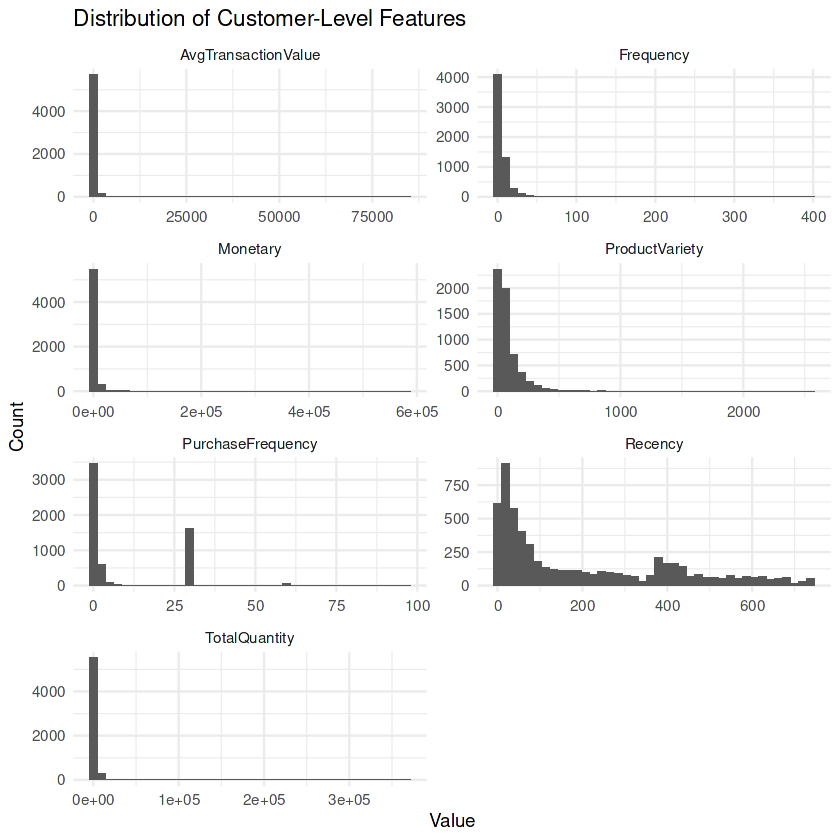

In [9]:
# 8. Exploratory visualization of customer features

feature_long <- customer_data_clean %>%
  select(CustomerID, all_of(model_features)) %>%
  pivot_longer(
    cols = all_of(model_features),
    names_to = "Feature",
    values_to = "Value"
  )

ggplot(feature_long, aes(x = Value)) +
  geom_histogram(bins = 40) +
  facet_wrap(~ Feature, scales = "free", ncol = 2) +
  labs(
    title = "Distribution of Customer-Level Features",
    x = "Value",
    y = "Count"
  ) +
  theme_minimal()

Elbow-based K estimate: 3 


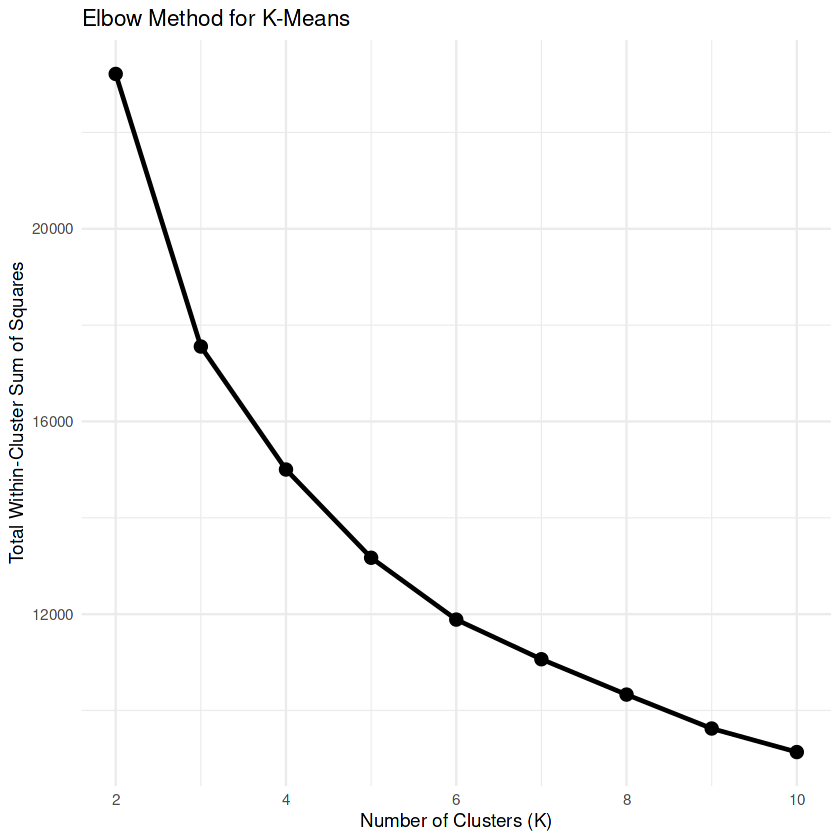

In [10]:
# 9. Elbow Method: within-cluster sum of squares

k_values <- 2:10

wss_values <- sapply(k_values, function(k) {
  km <- kmeans(
    scaled_df,
    centers = k,
    nstart = 25,
    iter.max = 100
  )
  km$tot.withinss
})

elbow_df <- data.frame(
  K = k_values,
  WSS = wss_values
)

ggplot(elbow_df, aes(x = K, y = WSS)) +
  geom_line(linewidth = 1) +
  geom_point(size = 3) +
  labs(
    title = "Elbow Method for K-Means",
    x = "Number of Clusters (K)",
    y = "Total Within-Cluster Sum of Squares"
  ) +
  theme_minimal()

# Second-difference heuristic for a reproducible elbow estimate.
first_diff <- diff(wss_values)
second_diff <- diff(first_diff)

k_elbow <- k_values[which.max(abs(second_diff)) + 1]
cat("Elbow-based K estimate:", k_elbow, "\n")

Elbow K estimate     : 3 
Best silhouette K    : 2 
Final K used         : 2 


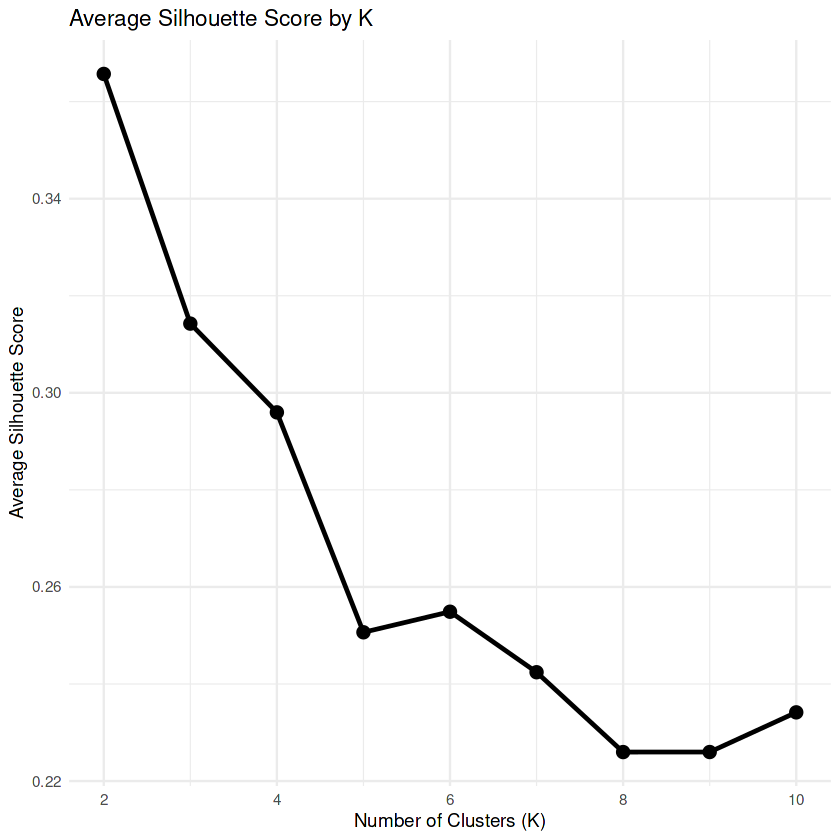

In [11]:
# 10. Silhouette analysis for candidate K values

silhouette_values <- sapply(k_values, function(k) {
  km <- kmeans(
    scaled_df,
    centers = k,
    nstart = 25,
    iter.max = 100
  )
  sil <- silhouette(km$cluster, dist(scaled_df))
  mean(sil[, "sil_width"])
})

silhouette_df <- data.frame(
  K = k_values,
  Silhouette = silhouette_values
)

ggplot(silhouette_df, aes(x = K, y = Silhouette)) +
  geom_line(linewidth = 1) +
  geom_point(size = 3) +
  labs(
    title = "Average Silhouette Score by K",
    x = "Number of Clusters (K)",
    y = "Average Silhouette Score"
  ) +
  theme_minimal()

k_silhouette <- k_values[which.max(silhouette_values)]

# Use the best silhouette K as the reproducible final K,
# while reporting the elbow estimate for comparison.
k_opt <- k_silhouette

cat("Elbow K estimate     :", k_elbow, "\n")
cat("Best silhouette K    :", k_silhouette, "\n")
cat("Final K used         :", k_opt, "\n")

In [12]:
# 11. Final K-Means clustering

kmeans_model <- kmeans(
  scaled_df,
  centers = k_opt,
  nstart = 50,
  iter.max = 200
)

customer_clusters <- customer_data_clean %>%
  mutate(Cluster = factor(kmeans_model$cluster))

cluster_sizes <- customer_clusters %>%
  count(Cluster, name = "Customers") %>%
  mutate(Percentage = round(Customers / sum(Customers) * 100, 2))

cluster_sizes

Cluster,Customers,Percentage
<fct>,<int>,<dbl>
1,3288,55.94
2,2590,44.06


K-Means average Silhouette Score: 0.3657 


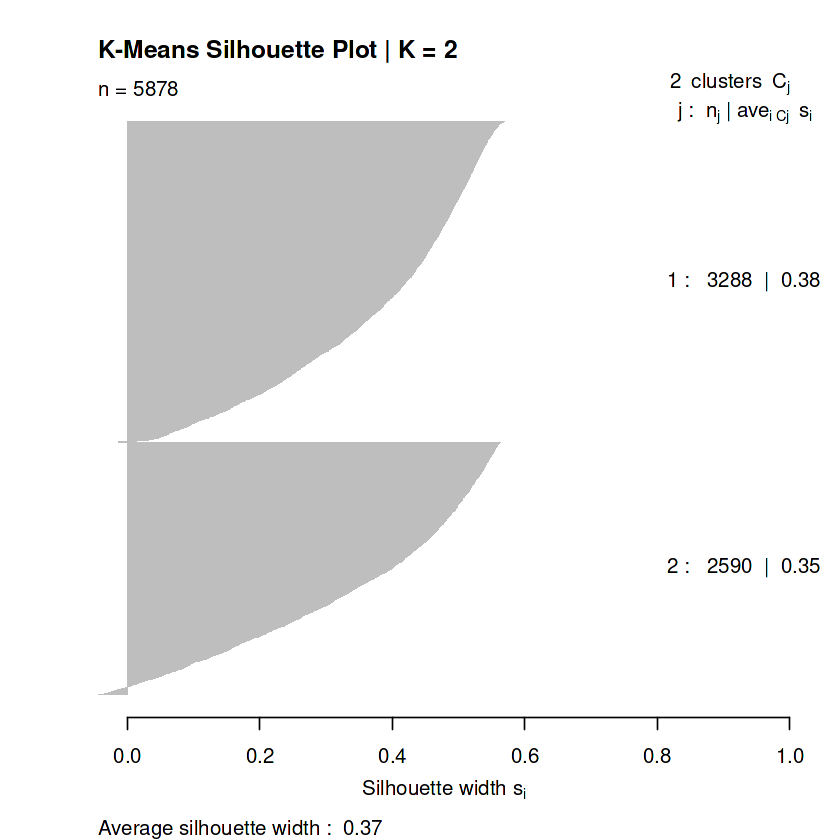

In [13]:
# 12. K-Means Silhouette Score and silhouette plot

kmeans_sil <- silhouette(kmeans_model$cluster, dist(scaled_df))
kmeans_silhouette_score <- mean(kmeans_sil[, "sil_width"])

cat("K-Means average Silhouette Score:",
    round(kmeans_silhouette_score, 4), "\n")

plot(
  kmeans_sil,
  border = NA,
  main = paste("K-Means Silhouette Plot | K =", k_opt)
)

Hierarchical average Silhouette Score: 0.3573 


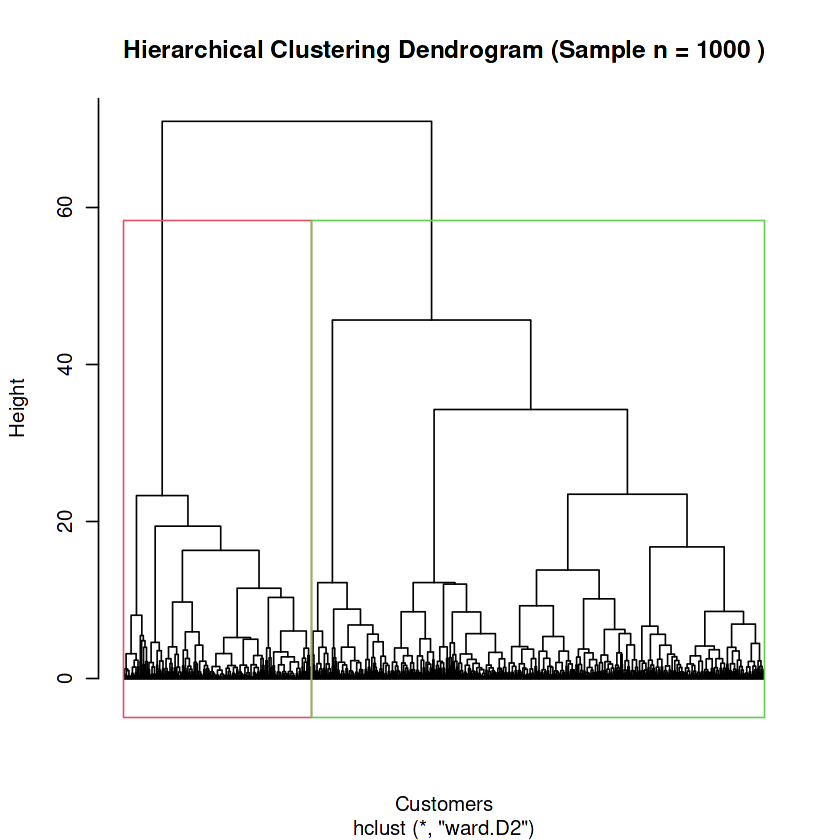

In [14]:
# 13. Hierarchical Clustering and Dendrogram
#    Ward.D2 linkage is used on a manageable customer sample.

set.seed(123)

hier_n <- min(1000, nrow(scaled_df))
hier_idx <- sample(seq_len(nrow(scaled_df)), hier_n)

hier_data <- scaled_df[hier_idx, , drop = FALSE]

hier_dist <- dist(hier_data, method = "euclidean")
hier_model <- hclust(hier_dist, method = "ward.D2")

plot(
  hier_model,
  labels = FALSE,
  hang = -1,
  main = paste("Hierarchical Clustering Dendrogram (Sample n =", hier_n, ")"),
  xlab = "Customers",
  ylab = "Height"
)

rect.hclust(
  hier_model,
  k = k_opt,
  border = 2:(k_opt + 1)
)

hier_clusters <- cutree(hier_model, k = k_opt)
hier_sil <- silhouette(hier_clusters, hier_dist)
hier_silhouette_score <- mean(hier_sil[, "sil_width"])

cat("Hierarchical average Silhouette Score:",
    round(hier_silhouette_score, 4), "\n")

In [15]:
# 14. Clustering quality comparison

clustering_comparison <- data.frame(
  Method = c("K-Means", "Hierarchical (Ward.D2)"),
  Silhouette_Score = c(
    kmeans_silhouette_score,
    hier_silhouette_score
  )
)

clustering_comparison

Method,Silhouette_Score
<chr>,<dbl>
K-Means,0.3657038
Hierarchical (Ward.D2),0.3573432


PC1 explained variance: 64.05 %
 PC2 explained variance: 14.85 %
 PC3 explained variance: 8.96 %


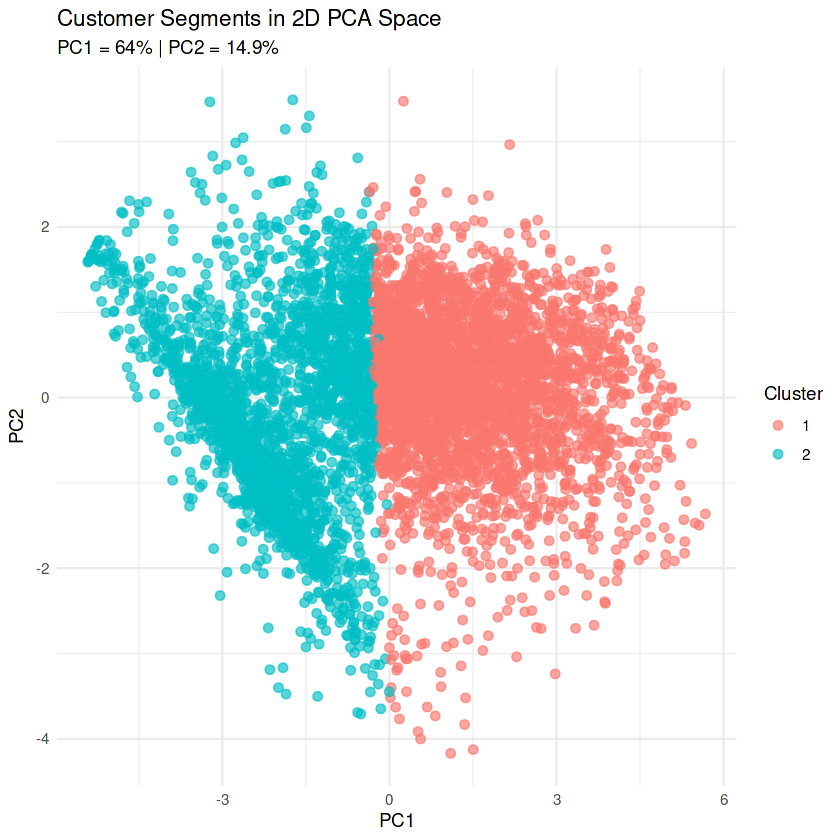

In [16]:
# 15. PCA for 2D visualization

pca_model <- prcomp(
  scaled_df,
  center = FALSE,
  scale. = FALSE
)

explained_variance <- (pca_model$sdev ^ 2) /
  sum(pca_model$sdev ^ 2)

pca_scores <- as.data.frame(pca_model$x[, 1:3])
names(pca_scores) <- c("PC1", "PC2", "PC3")

pca_scores$CustomerID <- customer_data_clean$CustomerID
pca_scores$Cluster <- factor(kmeans_model$cluster)

cat(
  "PC1 explained variance:", round(explained_variance[1] * 100, 2), "%\n",
  "PC2 explained variance:", round(explained_variance[2] * 100, 2), "%\n",
  "PC3 explained variance:", round(explained_variance[3] * 100, 2), "%\n"
)

ggplot(pca_scores, aes(PC1, PC2, color = Cluster)) +
  geom_point(alpha = 0.65, size = 2) +
  labs(
    title = "Customer Segments in 2D PCA Space",
    subtitle = paste0(
      "PC1 = ", round(explained_variance[1] * 100, 1),
      "% | PC2 = ", round(explained_variance[2] * 100, 1), "%"
    )
  ) +
  theme_minimal()

In [17]:
# 16. PCA loading analysis

loadings <- as.data.frame(pca_model$rotation[, 1:3])
loadings$Feature <- rownames(loadings)

loadings %>%
  select(Feature, PC1, PC2, PC3)

,Feature,PC1,PC2,PC3
,<chr>,<dbl>,<dbl>,<dbl>
Recency,Recency,-0.2979343,-0.373969507,-0.80680667
Frequency,Frequency,0.4135538,0.281493279,-0.04846443
Monetary,Monetary,0.4546446,-0.171158651,-0.02826437
AvgTransactionValue,AvgTransactionValue,0.2717693,-0.760886553,0.09888611
TotalQuantity,TotalQuantity,0.4458870,-0.146599918,-0.02045213
PurchaseFrequency,PurchaseFrequency,-0.3231173,-0.388711441,0.57004190
ProductVariety,ProductVariety,0.3955100,-0.008751656,-0.10378244


In [18]:
# 17. Interactive 3D Plotly visualization

plot_ly(
  pca_scores,
  x = ~PC1,
  y = ~PC2,
  z = ~PC3,
  color = ~Cluster,
  colors = "Set2",
  type = "scatter3d",
  mode = "markers",
  text = ~paste(
    "Customer:", CustomerID,
    "<br>Cluster:", Cluster,
    "<br>PC1:", round(PC1, 2),
    "<br>PC2:", round(PC2, 2),
    "<br>PC3:", round(PC3, 2)
  ),
  hoverinfo = "text",
  marker = list(size = 4, opacity = 0.7)
) %>%
  layout(
    title = "Interactive 3D PCA Customer Segmentation",
    scene = list(
      xaxis = list(title = "PC1"),
      yaxis = list(title = "PC2"),
      zaxis = list(title = "PC3")
    )
  )

HTML widgets cannot be represented in plain text (need html)

In [19]:
# 18. Cluster-wise customer profiling

cluster_profile <- customer_clusters %>%
  group_by(Cluster) %>%
  summarise(
    Customers = n(),
    Recency_Median = median(Recency, na.rm = TRUE),
    Frequency_Median = median(Frequency, na.rm = TRUE),
    Monetary_Median = median(Monetary, na.rm = TRUE),
    Avg_Transaction_Value_Median = median(
      AvgTransactionValue, na.rm = TRUE
    ),
    Total_Quantity_Median = median(TotalQuantity, na.rm = TRUE),
    Purchase_Frequency_Median = median(
      PurchaseFrequency, na.rm = TRUE
    ),
    Product_Variety_Median = median(ProductVariety, na.rm = TRUE),
    Monetary_Mean = mean(Monetary, na.rm = TRUE),
    .groups = "drop"
  )

cluster_profile

Cluster,Customers,Recency_Median,Frequency_Median,Monetary_Median,Avg_Transaction_Value_Median,Total_Quantity_Median,Purchase_Frequency_Median,Product_Variety_Median,Monetary_Mean
<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,3288,40.96111,6,1973.87,334.984,1151,0.5210469,89,4979.9766
2,2590,366.93542,1,309.27,195.455,162,30.0000000,18,386.3479


In [20]:
# 19. Automatic segment naming based on relative behavior

global_medians <- customer_clusters %>%
  summarise(
    Recency = median(Recency, na.rm = TRUE),
    Frequency = median(Frequency, na.rm = TRUE),
    Monetary = median(Monetary, na.rm = TRUE)
  )

cluster_profile <- cluster_profile %>%
  mutate(
    Segment_Name = case_when(
      Monetary_Median >= global_medians$Monetary &
        Frequency_Median >= global_medians$Frequency &
        Recency_Median <= global_medians$Recency
        ~ "Champions / High-Value",

      Frequency_Median >= global_medians$Frequency &
        Monetary_Median >= global_medians$Monetary
        ~ "Loyal / High-Potential",

      Recency_Median > global_medians$Recency &
        Monetary_Median >= global_medians$Monetary
        ~ "At-Risk High-Value",

      Frequency_Median < global_medians$Frequency &
        Monetary_Median < global_medians$Monetary
        ~ "Occasional / Low-Value",

      TRUE ~ "Developing Customers"
    )
  )

cluster_profile %>%
  arrange(desc(Monetary_Median))

Cluster,Customers,Recency_Median,Frequency_Median,Monetary_Median,Avg_Transaction_Value_Median,Total_Quantity_Median,Purchase_Frequency_Median,Product_Variety_Median,Monetary_Mean,Segment_Name
<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,3288,40.96111,6,1973.87,334.984,1151,0.5210469,89,4979.9766,Champions / High-Value
2,2590,366.93542,1,309.27,195.455,162,30.0000000,18,386.3479,Occasional / Low-Value


In [21]:
# 20. High-value segment identification
#    Select the cluster with the highest median Monetary value.

high_value_cluster <- cluster_profile %>%
  arrange(desc(Monetary_Median)) %>%
  slice(1) %>%
  pull(Cluster)

high_value_name <- cluster_profile %>%
  filter(Cluster == high_value_cluster) %>%
  pull(Segment_Name)

cat("High-value cluster:", as.character(high_value_cluster), "\n")
cat("High-value segment:", high_value_name, "\n")

customer_clusters <- customer_clusters %>%
  mutate(
    High_Value = factor(
      ifelse(
        Cluster == high_value_cluster,
        "High_Value",
        "Not_High_Value"
      ),
      levels = c("Not_High_Value", "High_Value")
    )
  )

table(customer_clusters$High_Value)

High-value cluster: 1 
High-value segment: Champions / High-Value 



Not_High_Value     High_Value 
          2590           3288 

In [22]:
# 21. Prepare supervised-learning data
#    Use customer features only; do not use CustomerID or Cluster.

supervised_data <- customer_clusters %>%
  select(
    CustomerID,
    all_of(model_features),
    High_Value
  ) %>%
  mutate(High_Value = factor(
    High_Value,
    levels = c("Not_High_Value", "High_Value")
  ))

# Recreate the same robust preprocessing for the classifier.
x_raw <- supervised_data[, model_features, drop = FALSE]

for (f in model_features) {
  x_raw[[f]] <- winsorize(x_raw[[f]])
  x_raw[[f]] <- log1p(x_raw[[f]])
}

x_scaled <- scale(x_raw)

model_df <- as.data.frame(x_scaled)
names(model_df) <- model_features
model_df$High_Value <- supervised_data$High_Value

# Remove any non-finite rows defensively.
keep <- apply(
  model_df[, model_features, drop = FALSE],
  1,
  function(z) all(is.finite(z))
)

model_df <- model_df[keep, , drop = FALSE]

cat("Modeling rows:", nrow(model_df), "\n")
print(prop.table(table(model_df$High_Value)))

Modeling rows: 5878 

Not_High_Value     High_Value 
     0.4406261      0.5593739 


In [23]:
# 22. Stratified train-test split

set.seed(123)

train_indices <- unlist(lapply(
  split(seq_len(nrow(model_df)), model_df$High_Value),
  function(idx) {
    n_train <- max(1, floor(0.80 * length(idx)))
    sample(idx, n_train)
  }
))

train_df <- model_df[sort(train_indices), , drop = FALSE]
test_df <- model_df[-sort(train_indices), , drop = FALSE]

cat("Training rows:", nrow(train_df), "\n")
cat("Testing rows :", nrow(test_df), "\n")

cat("\nTraining class distribution:\n")
print(prop.table(table(train_df$High_Value)))

cat("\nTesting class distribution:\n")
print(prop.table(table(test_df$High_Value)))

Training rows: 4702 
Testing rows : 1176 

Training class distribution:

Not_High_Value     High_Value 
     0.4406635      0.5593365 

Testing class distribution:

Not_High_Value     High_Value 
     0.4404762      0.5595238 


In [24]:
# 23. Random Forest model

set.seed(123)

rf_model <- randomForest(
  High_Value ~ .,
  data = train_df[, c(model_features, "High_Value")],
  ntree = 400,
  importance = TRUE
)

rf_prob <- predict(
  rf_model,
  newdata = test_df[, model_features, drop = FALSE],
  type = "prob"
)[, "High_Value"]

rf_pred <- factor(
  ifelse(rf_prob >= 0.50, "High_Value", "Not_High_Value"),
  levels = c("Not_High_Value", "High_Value")
)

print(rf_model)


Call:
 randomForest(formula = High_Value ~ ., data = train_df[, c(model_features,      "High_Value")], ntree = 400, importance = TRUE) 
               Type of random forest: classification
                     Number of trees: 400
No. of variables tried at each split: 2

        OOB estimate of  error rate: 1.68%
Confusion matrix:
               Not_High_Value High_Value class.error
Not_High_Value           2031         41  0.01978764
High_Value                 38       2592  0.01444867


In [25]:
# 24. SVM model with probability estimates

set.seed(123)

svm_model <- svm(
  High_Value ~ .,
  data = train_df[, c(model_features, "High_Value")],
  kernel = "radial",
  probability = TRUE,
  scale = FALSE
)

svm_pred_obj <- predict(
  svm_model,
  newdata = test_df[, model_features, drop = FALSE],
  probability = TRUE
)

svm_prob <- attr(svm_pred_obj, "probabilities")[, "High_Value"]

svm_pred <- factor(
  ifelse(svm_prob >= 0.50, "High_Value", "Not_High_Value"),
  levels = c("Not_High_Value", "High_Value")
)

print(svm_model)


Call:
svm(formula = High_Value ~ ., data = train_df[, c(model_features, 
    "High_Value")], kernel = "radial", probability = TRUE, scale = FALSE)


Parameters:
   SVM-Type:  C-classification 
 SVM-Kernel:  radial 
       cost:  1 

Number of Support Vectors:  335



In [26]:
# 25. Classification metrics

classification_metrics <- function(actual, predicted, probability) {
  actual <- factor(
    actual,
    levels = c("Not_High_Value", "High_Value")
  )
  predicted <- factor(
    predicted,
    levels = c("Not_High_Value", "High_Value")
  )

  cm <- table(
    Actual = actual,
    Predicted = predicted
  )

  tn <- cm["Not_High_Value", "Not_High_Value"]
  fp <- cm["Not_High_Value", "High_Value"]
  fn <- cm["High_Value", "Not_High_Value"]
  tp <- cm["High_Value", "High_Value"]

  accuracy <- (tp + tn) / sum(cm)
  precision <- ifelse(tp + fp == 0, 0, tp / (tp + fp))
  recall <- ifelse(tp + fn == 0, 0, tp / (tp + fn))
  f1 <- ifelse(
    precision + recall == 0,
    0,
    2 * precision * recall / (precision + recall)
  )

  roc_obj <- pROC::roc(
    response = actual,
    predictor = probability,
    levels = c("Not_High_Value", "High_Value"),
    direction = "<",
    quiet = TRUE
  )

  auc <- as.numeric(pROC::auc(roc_obj))

  list(
    metrics = data.frame(
      Accuracy = accuracy,
      Precision = precision,
      Recall = recall,
      F1_Score = f1,
      ROC_AUC = auc
    ),
    confusion_matrix = cm,
    roc = roc_obj
  )
}

rf_results <- classification_metrics(
  test_df$High_Value,
  rf_pred,
  rf_prob
)

svm_results <- classification_metrics(
  test_df$High_Value,
  svm_pred,
  svm_prob
)

performance_comparison <- bind_rows(
  Random_Forest = rf_results$metrics,
  SVM = svm_results$metrics,
  .id = "Model"
)

performance_comparison

Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Random_Forest,0.9897959,0.9835329,0.9984802,0.9909502,0.9994822
SVM,0.9948980,0.9909639,1.0000000,0.9954614,0.9999912


                Predicted
Actual           Not_High_Value High_Value
  Not_High_Value            507         11
  High_Value                  1        657

                Predicted
Actual           Not_High_Value High_Value
  Not_High_Value            512          6
  High_Value                  0        658

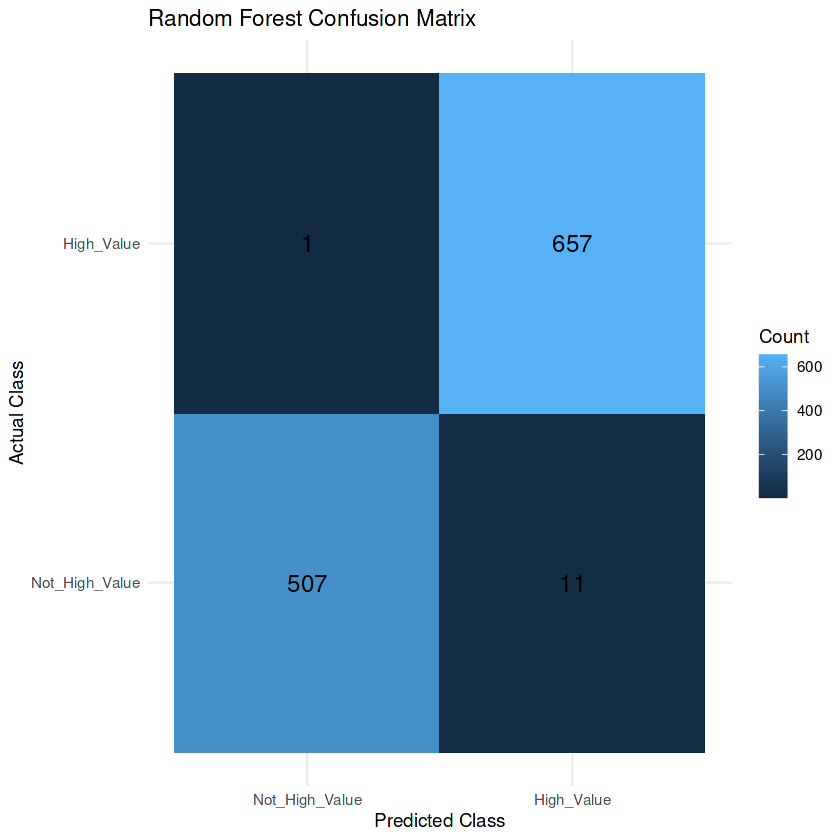

In [27]:
# 26. Confusion matrices

rf_results$confusion_matrix
svm_results$confusion_matrix

# Heatmap for Random Forest confusion matrix
rf_cm_df <- as.data.frame(rf_results$confusion_matrix)
names(rf_cm_df) <- c("Actual", "Predicted", "Count")

ggplot(rf_cm_df, aes(Predicted, Actual, fill = Count)) +
  geom_tile() +
  geom_text(aes(label = Count), size = 5) +
  labs(
    title = "Random Forest Confusion Matrix",
    x = "Predicted Class",
    y = "Actual Class"
  ) +
  theme_minimal()

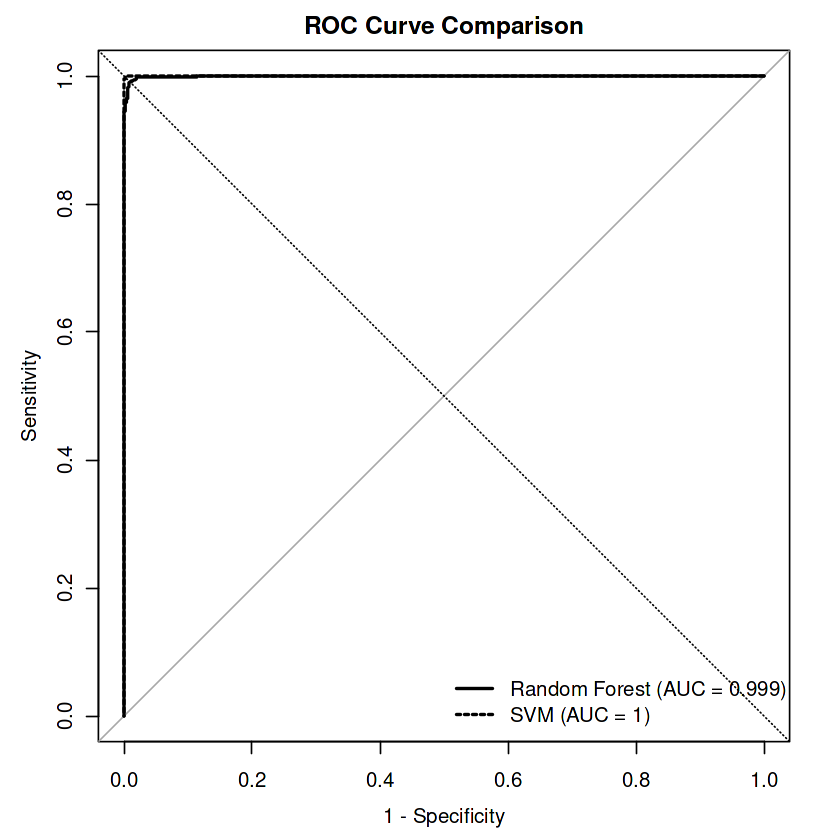

In [28]:
# 27. ROC curves: Random Forest vs SVM

plot(
  rf_results$roc,
  lwd = 2,
  legacy.axes = TRUE,
  main = "ROC Curve Comparison"
)

lines(
  svm_results$roc,
  lwd = 2,
  lty = 2
)

abline(0, 1, lty = 3)

legend(
  "bottomright",
  legend = c(
    paste0("Random Forest (AUC = ", round(rf_results$metrics$ROC_AUC, 3), ")"),
    paste0("SVM (AUC = ", round(svm_results$metrics$ROC_AUC, 3), ")")
  ),
  lty = c(1, 2),
  lwd = 2,
  bty = "n"
)

Feature,MeanDecreaseAccuracy
<chr>,<dbl>
Recency,69.11452
Monetary,42.27262
ProductVariety,39.09580
TotalQuantity,31.56013
PurchaseFrequency,31.53002
AvgTransactionValue,22.42772
Frequency,20.46181


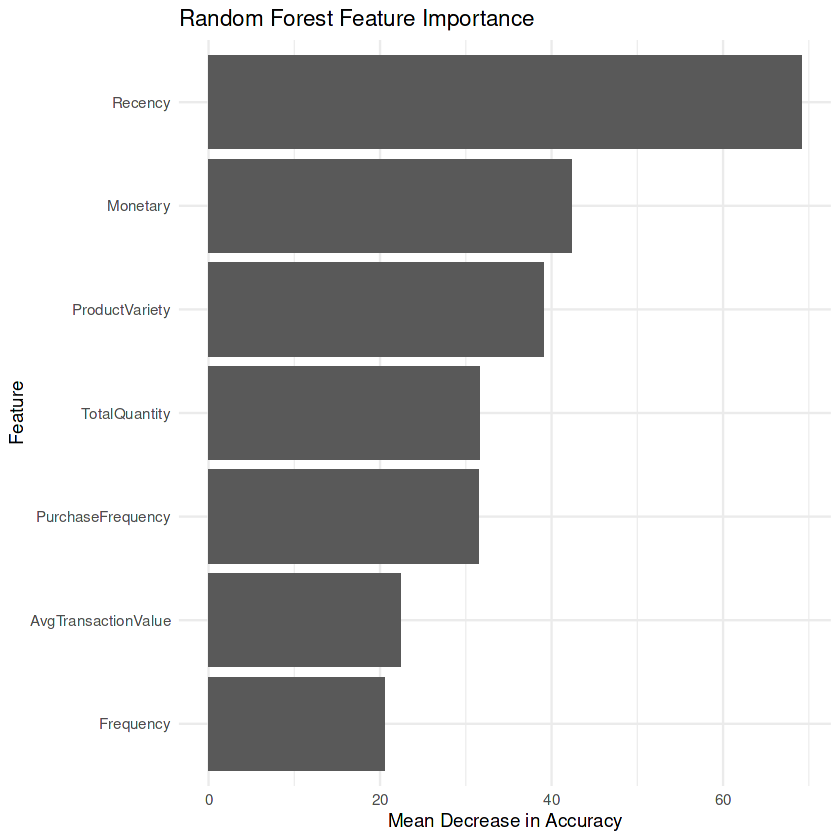

In [29]:
# 28. Feature importance analysis for Random Forest

rf_importance <- importance(rf_model, type = 1)

rf_importance_df <- data.frame(
  Feature = rownames(rf_importance),
  MeanDecreaseAccuracy = rf_importance[, 1],
  row.names = NULL
) %>%
  arrange(desc(MeanDecreaseAccuracy))

rf_importance_df

ggplot(
  rf_importance_df,
  aes(
    x = reorder(Feature, MeanDecreaseAccuracy),
    y = MeanDecreaseAccuracy
  )
) +
  geom_col() +
  coord_flip() +
  labs(
    title = "Random Forest Feature Importance",
    x = "Feature",
    y = "Mean Decrease in Accuracy"
  ) +
  theme_minimal()

In [30]:
# 29. Business-oriented cluster comparison

cluster_profile_display <- cluster_profile %>%
  mutate(
    Share_Percent = round(Customers / sum(Customers) * 100, 2),
    Median_Revenue_Label = paste0("£", comma(round(Monetary_Median, 2))),
    Median_Frequency_Label = comma(round(Frequency_Median, 1))
  ) %>%
  select(
    Cluster,
    Segment_Name,
    Customers,
    Share_Percent,
    Recency_Median,
    Frequency_Median,
    Monetary_Median,
    Avg_Transaction_Value_Median,
    Total_Quantity_Median,
    Purchase_Frequency_Median,
    Product_Variety_Median
  ) %>%
  arrange(Cluster)

cluster_profile_display

Cluster,Segment_Name,Customers,Share_Percent,Recency_Median,Frequency_Median,Monetary_Median,Avg_Transaction_Value_Median,Total_Quantity_Median,Purchase_Frequency_Median,Product_Variety_Median
<fct>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Champions / High-Value,3288,55.94,40.96111,6,1973.87,334.984,1151,0.5210469,89
2,Occasional / Low-Value,2590,44.06,366.93542,1,309.27,195.455,162,30.0000000,18


In [31]:
# 30. Segment-wise targeted marketing recommendations
#    Rule-based recommendations driven by customer behavior.

marketing_recommendations <- cluster_profile %>%
  rowwise() %>%
  mutate(
    Marketing_Strategy = case_when(
      Segment_Name == "Champions / High-Value" ~
        "VIP rewards, early access, premium bundles, loyalty benefits, and personalized cross-sell.",

      Segment_Name == "Loyal / High-Potential" ~
        "Tiered loyalty incentives, repeat-purchase offers, product recommendations, and bundles.",

      Segment_Name == "At-Risk High-Value" ~
        "Win-back campaigns, personalized reminders, limited-time incentives, and service follow-up.",

      Segment_Name == "Occasional / Low-Value" ~
        "Low-cost promotions, recommendation emails, cross-sell campaigns, and first-to-second-purchase offers.",

      TRUE ~
        "Nurture campaigns, educational content, personalized recommendations, and gradual loyalty incentives."
    ),

    Primary_KPI = case_when(
      Segment_Name == "Champions / High-Value" ~ "Retention and customer lifetime value",
      Segment_Name == "Loyal / High-Potential" ~ "Repeat purchase rate",
      Segment_Name == "At-Risk High-Value" ~ "Reactivation rate",
      Segment_Name == "Occasional / Low-Value" ~ "Conversion and purchase frequency",
      TRUE ~ "Engagement and second-purchase rate"
    )
  ) %>%
  ungroup() %>%
  select(
    Cluster,
    Segment_Name,
    Marketing_Strategy,
    Primary_KPI
  )

marketing_recommendations

Cluster,Segment_Name,Marketing_Strategy,Primary_KPI
<fct>,<chr>,<chr>,<chr>
1,Champions / High-Value,"VIP rewards, early access, premium bundles, loyalty benefits, and personalized cross-sell.",Retention and customer lifetime value
2,Occasional / Low-Value,"Low-cost promotions, recommendation emails, cross-sell campaigns, and first-to-second-purchase offers.",Conversion and purchase frequency


In [32]:
# 31. Final interpretation summary

cat("============================================================\n")
cat("FINAL RESULTS SUMMARY\n")
cat("============================================================\n")

cat("Number of customers analyzed:", nrow(customer_clusters), "\n")
cat("Selected K:", k_opt, "\n")
cat("Elbow K estimate:", k_elbow, "\n")
cat("K-Means Silhouette:", round(kmeans_silhouette_score, 4), "\n")
cat("Hierarchical Silhouette (sample):", round(hier_silhouette_score, 4), "\n")
cat("High-value cluster:", as.character(high_value_cluster), "\n")
cat("High-value segment name:", high_value_name, "\n\n")

print(performance_comparison)

cat("\nBusiness interpretation:\n")
cat("- Recency measures how recently customers purchased. Lower values indicate more recent activity.\n")
cat("- Frequency measures the number of distinct invoices and reflects repeat purchasing.\n")
cat("- Monetary measures total customer revenue and is the main value indicator.\n")
cat("- Behavioral features such as transaction value, quantity, purchase frequency, and product variety enrich the segmentation beyond basic RFM.\n")
cat("- Use the cluster profiles to tailor retention, loyalty, win-back, and acquisition/nurture strategies.\n")

FINAL RESULTS SUMMARY
Number of customers analyzed: 5878 
Selected K: 2 
Elbow K estimate: 3 
K-Means Silhouette: 0.3657 
Hierarchical Silhouette (sample): 0.3573 
High-value cluster: 1 
High-value segment name: Champions / High-Value 

          Model  Accuracy Precision    Recall  F1_Score   ROC_AUC
1 Random_Forest 0.9897959 0.9835329 0.9984802 0.9909502 0.9994822
2           SVM 0.9948980 0.9909639 1.0000000 0.9954614 0.9999912

Business interpretation:
- Recency measures how recently customers purchased. Lower values indicate more recent activity.
- Frequency measures the number of distinct invoices and reflects repeat purchasing.
- Monetary measures total customer revenue and is the main value indicator.
- Behavioral features such as transaction value, quantity, purchase frequency, and product variety enrich the segmentation beyond basic RFM.
- Use the cluster profiles to tailor retention, loyalty, win-back, and acquisition/nurture strategies.


## Conclusion

This notebook implements the complete customer segmentation and predictive analytics workflow requested in the laboratory problem statement.

### Key outputs produced
- Data preprocessing and missing-value handling
- Cancellation and non-positive transaction removal
- Customer-level RFM and behavioral feature engineering
- Outlier treatment and feature scaling
- Elbow Method and Silhouette analysis
- K-Means customer segmentation
- Hierarchical clustering and dendrogram
- Clustering quality comparison
- PCA-based 2D visualization
- Interactive 3D Plotly visualization
- Cluster profiling and automatic segment naming
- High-value segment identification
- Random Forest and SVM classification
- Accuracy, Precision, Recall, F1-Score and ROC-AUC
- Confusion Matrix and ROC comparison
- Random Forest feature importance
- Segment-wise marketing recommendations

### Git submission placeholder
Replace the line below with your repository URL before submitting:

`Git Repository: <PASTE-YOUR-GITHUB-REPOSITORY-LINK-HERE>`

In [33]:
# 32. Save important results as CSV files for submission

write.csv(
  customer_clusters,
  "/kaggle/working/customer_segments.csv",
  row.names = FALSE
)

write.csv(
  cluster_profile_display,
  "/kaggle/working/cluster_profiles.csv",
  row.names = FALSE
)

write.csv(
  performance_comparison,
  "/kaggle/working/model_performance.csv",
  row.names = FALSE
)

write.csv(
  marketing_recommendations,
  "/kaggle/working/marketing_recommendations.csv",
  row.names = FALSE
)

cat("Saved result files to /kaggle/working/\n")

Saved result files to /kaggle/working/


In [34]:
# 33. Reproducibility information

sessionInfo()

R version 4.4.0 (2024-04-24)
Platform: x86_64-pc-linux-gnu
Running under: Ubuntu 22.04.4 LTS

Matrix products: default
BLAS:   /usr/lib/x86_64-linux-gnu/openblas-pthread/libblas.so.3 
LAPACK: /usr/lib/x86_64-linux-gnu/openblas-pthread/libopenblasp-r0.3.20.so;  LAPACK version 3.10.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Etc/UTC
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] scales_1.3.0         plotly_4.10.4        pROC_1.18.5         
 [4] e1071_1.7-16         randomForest_4.7-1.2 cluster_2.1.8       
 [7] readxl_1.4.3         lubridate_1.9.4  